In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
import joblib
%matplotlib inline


In [3]:
#DATA COLLECTION
np.random.seed(42)
n=300
df=pd.DataFrame({
    'Area_sqft'    : np.random.randint(500, 5000, n),
    'Bedrooms'     : np.random.randint(1, 6, n),
    'Bathrooms'    : np.random.randint(1, 4, n),
    'Age_of_House' : np.random.randint(1, 50, n),
    'Garage'       : np.random.choice(['Yes', 'No'], n),
    'Location'     : np.random.choice(['Urban', 'Suburb', 'Rural'], n),
})

df['Price'] = (
    df['Area_sqft']    * 150 +
    df['Bedrooms']     * 10000 +
    df['Bathrooms']    * 8000 -
    df['Age_of_House'] * 500 +
    (df['Garage'] == 'Yes').astype(int) * 15000 +
    np.random.randint(-20000, 20000, n)
)
print("Shape:", df.shape)
display(df.head())

Shape: (300, 7)


,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Garage,Location,Price
0,1360,4,1,4,Yes,Rural,271431
1,4272,3,1,19,No,Rural,668740
2,3592,4,2,20,No,Rural,581975
3,966,2,3,33,Yes,Rural,193785
4,4926,2,1,20,No,Urban,775058


In [4]:
#DATA CLEANING
print("Missing Values:\n",df.isnull().sum())
print("\nDuplicate Rows",df.duplicated().sum())

#removes negatives if any
df=df[df['Price']>0]

print("\nData cleaned.")
print("Final Shape:",df.shape)

Missing Values:
 Area_sqft       0
Bedrooms        0
Bathrooms       0
Age_of_House    0
Garage          0
Location        0
Price           0
dtype: int64

Duplicate Rows 0

Data cleaned.
Final Shape: (300, 7)


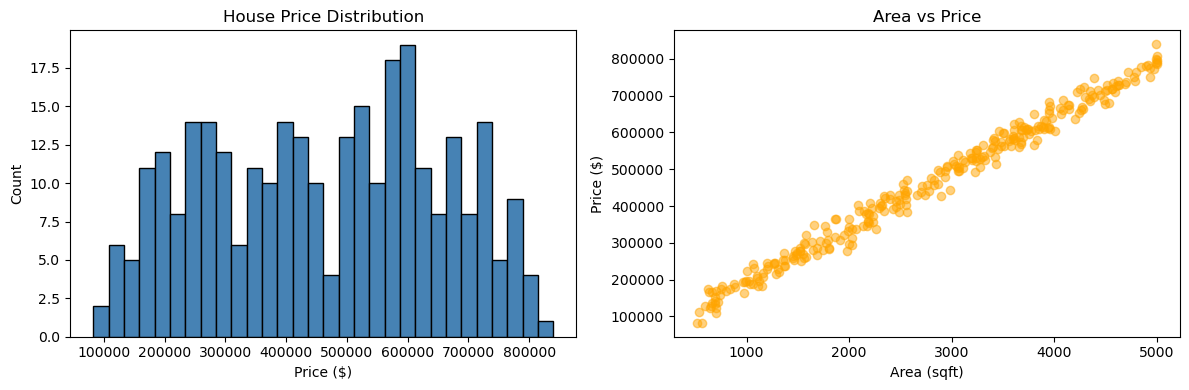

In [5]:
#EDA-PRICE DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("House Price Distribution")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

axes[1].scatter(df['Area_sqft'], df['Price'], color='orange', alpha=0.5)
axes[1].set_title("Area vs Price")
axes[1].set_xlabel("Area (sqft)")
axes[1].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

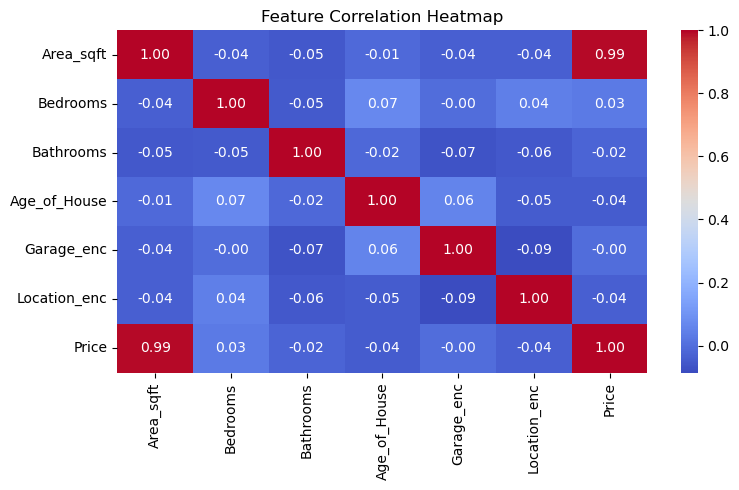

💡 Closer to 1 or -1 = stronger effect on Price!


In [6]:
#EDA-CORRELATION HEATMAP
df['Garage_enc']   = LabelEncoder().fit_transform(df['Garage'])
df['Location_enc'] = LabelEncoder().fit_transform(df['Location'])

corr = df[['Area_sqft','Bedrooms','Bathrooms','Age_of_House',
           'Garage_enc','Location_enc','Price']].corr()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

print("💡 Closer to 1 or -1 = stronger effect on Price!")

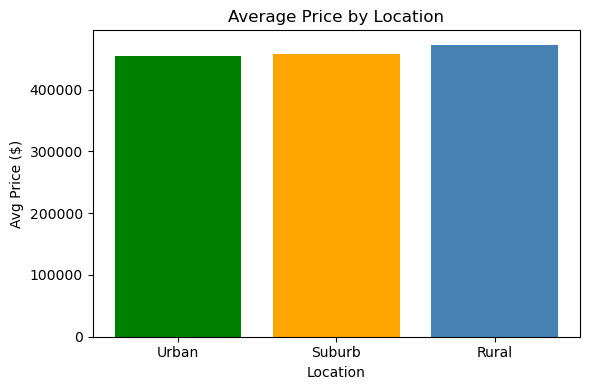

In [7]:
#EDA-AVERAGE PRICE BY LOCATION
avg_location = df.groupby('Location')['Price'].mean().sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(avg_location.index, avg_location.values, color=['green','orange','steelblue'])
ax.set_title("Average Price by Location")
ax.set_xlabel("Location")
ax.set_ylabel("Avg Price ($)")
plt.tight_layout()
plt.show()

In [8]:
#FEATURE SELECTION + SPLIT
X = df[['Area_sqft','Bedrooms','Bathrooms','Age_of_House','Garage_enc','Location_enc']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Split Done!")
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Split Done!
Train: (240, 6)
Test : (60, 6)


In [9]:
#TRAIN MODEL
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)

print("=" * 40)
print("      MODEL EVALUATION")
print("=" * 40)
print(f"  RMSE : ${rmse:,.0f}")
print(f"  R²   : {r2:.4f} ({r2*100:.1f}%)")
print("=" * 40)

if r2 >= 0.9:
    print("Excellent Model!")
elif r2 >= 0.75:
    print("Good Model!")
else:
    print("Needs improvement")

      MODEL EVALUATION
  RMSE : $11,333
  R²   : 0.9964 (99.6%)
Excellent Model!


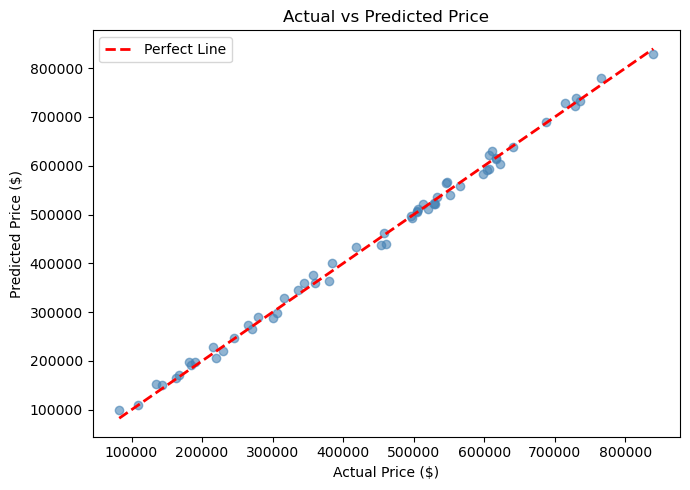

In [10]:
#ACTUAL vs PREDICTED CHART
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linewidth=2, linestyle='--', label='Perfect Line')
ax.set_title("Actual vs Predicted Price")
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
#SAVE THE MODEL
joblib.dump(model, 'house_price_model.pkl')
print("Model Saved as house_price_model.pkl")

Model Saved as house_price_model.pkl


# *Streamlit app*

In [12]:
!pip install streamlit

In [13]:
!streamlit --version

Streamlit, version 1.37.1


In [14]:
%%writefile app.py

import streamlit as st
st.title("Hello! Streamlit.")

Overwriting app.py


In [15]:
#checking if the app.py file has been created .
import os
print(os.listdir('.'))   

['.ipynb_checkpoints', 'app.py', 'bar_chart.png', 'cleaned_titanic.csv', 'csv to dashboard.ipynb', 'Customer Segmentation.ipynb', 'data cleaning and preprocessing.ipynb', 'data visualization.ipynb', 'EDA.ipynb', 'histogram.png', 'House Price Prediction.ipynb', 'house_price_model.pkl', 'iris.csv', 'Mall_Customers.csv', 'ML Model.ipynb', 'netflix_titles.csv', 'pairplot.png', 'Sales data analysis.ipynb', 'scatter_plot.png', 'Time series analysis.ipynb', 'titanic.csv', 'Untitled.ipynb']


In [ ]:
import os
print("app.py exists:",os.path.exists('app.py'))